In [1]:
# ============================================================
# Notebook 02 — Preprocesamiento de datos
# Sistema de detección de apnea del sueño
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)

# Cargar los datos generados en el Notebook 01
ruta = Path('../data/simulated')

X = pd.read_csv(ruta / 'X_datos.csv').values
y = pd.read_csv(ruta / 'y_etiquetas.csv').values.ravel()

print(f"✓ X cargado: {X.shape}")
print(f"✓ y cargado: {y.shape}")
print(f"✓ Clases presentes: {np.unique(y, return_counts=True)}")

✓ X cargado: (600, 300)
✓ y cargado: (600,)
✓ Clases presentes: (array([0, 1, 2]), array([300, 150, 150]))


✓ Antes de normalizar — min: -1.332, max: 1.323
✓ Después de normalizar — min: 0.000, max: 1.000


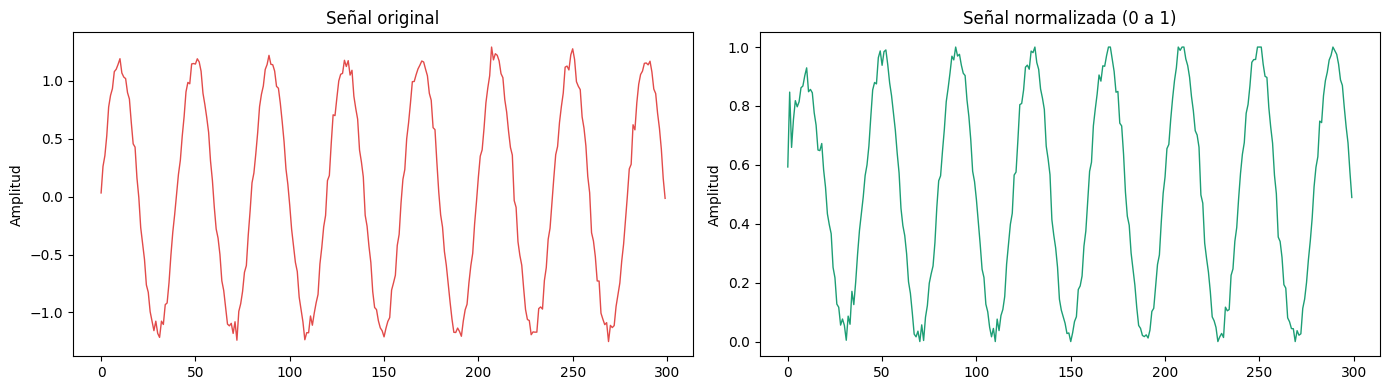

✓ Normalización completada


In [2]:
# ============================================================
# Normalización
# Llevamos todos los valores al rango 0-1
# ============================================================

scaler = MinMaxScaler()
X_normalizado = scaler.fit_transform(X)

print(f"✓ Antes de normalizar — min: {X.min():.3f}, max: {X.max():.3f}")
print(f"✓ Después de normalizar — min: {X_normalizado.min():.3f}, max: {X_normalizado.max():.3f}")

# Verificar visualmente la diferencia
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(X[0], color='#E24B4A', linewidth=1)
axes[0].set_title('Señal original')
axes[0].set_ylabel('Amplitud')

axes[1].plot(X_normalizado[0], color='#1D9E75', linewidth=1)
axes[1].set_title('Señal normalizada (0 a 1)')
axes[1].set_ylabel('Amplitud')

plt.tight_layout()
plt.show()

print("✓ Normalización completada")

In [3]:
# ============================================================
# División del dataset
# 70% entrenar, 15% validar, 15% probar
# ============================================================

# Primera división: 70% entrenamiento, 30% resto
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalizado, y,
    test_size=0.30,
    random_state=42,
    stratify=y        # mantiene proporción de clases en cada parte
)

# Segunda división: el 30% lo partimos en validación y prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"✓ Entrenamiento: {X_train.shape[0]} ejemplos ({X_train.shape[0]/600*100:.0f}%)")
print(f"✓ Validación:    {X_val.shape[0]} ejemplos ({X_val.shape[0]/600*100:.0f}%)")
print(f"✓ Prueba:        {X_test.shape[0]} ejemplos ({X_test.shape[0]/600*100:.0f}%)")

✓ Entrenamiento: 420 ejemplos (70%)
✓ Validación:    90 ejemplos (15%)
✓ Prueba:        90 ejemplos (15%)


In [4]:
python# ============================================================
# Reshape para LSTM
# La red espera datos en formato (muestras, pasos, características)
# ============================================================

X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_lstm   = X_val.reshape(X_val.shape[0],   X_val.shape[1],   1)
X_test_lstm  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f"✓ Forma entrenamiento: {X_train_lstm.shape}")
print(f"✓ Forma validación:    {X_val_lstm.shape}")
print(f"✓ Forma prueba:        {X_test_lstm.shape}")
print(f"\n  Interpretación: (ejemplos, pasos de tiempo, características)")

NameError: name 'python' is not defined

In [5]:
# ============================================================
# Reshape para LSTM
# La red espera datos en formato (muestras, pasos, características)
# ============================================================

X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_lstm   = X_val.reshape(X_val.shape[0],   X_val.shape[1],   1)
X_test_lstm  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f"✓ Forma entrenamiento: {X_train_lstm.shape}")
print(f"✓ Forma validación:    {X_val_lstm.shape}")
print(f"✓ Forma prueba:        {X_test_lstm.shape}")
print(f"\n  Interpretación: (ejemplos, pasos de tiempo, características)")

✓ Forma entrenamiento: (420, 300, 1)
✓ Forma validación:    (90, 300, 1)
✓ Forma prueba:        (90, 300, 1)

  Interpretación: (ejemplos, pasos de tiempo, características)


In [6]:
# ============================================================
# Guardar datos preprocesados
# ============================================================

ruta_salida = Path('../data/simulated')

np.save(ruta_salida / 'X_train.npy', X_train_lstm)
np.save(ruta_salida / 'X_val.npy',   X_val_lstm)
np.save(ruta_salida / 'X_test.npy',  X_test_lstm)
np.save(ruta_salida / 'y_train.npy', y_train)
np.save(ruta_salida / 'y_val.npy',   y_val)
np.save(ruta_salida / 'y_test.npy',  y_test)

# Guardar el scaler para usarlo después en la app
import pickle
with open(ruta_salida / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✓ Archivos guardados:")
print("   X_train.npy / X_val.npy / X_test.npy")
print("   y_train.npy / y_val.npy / y_test.npy")
print("   scaler.pkl")
print(f"\n✓ Notebook 02 completado — datos listos para la LSTM")

✓ Archivos guardados:
   X_train.npy / X_val.npy / X_test.npy
   y_train.npy / y_val.npy / y_test.npy
   scaler.pkl

✓ Notebook 02 completado — datos listos para la LSTM


In [7]:
git add .
git commit -m "feat: notebook 02 — data preprocessing and LSTM reshape (420/90/90 split)"
git push origin main

SyntaxError: invalid syntax (2037503771.py, line 1)

In [8]:
git add .
git commit -m "feat: notebook 02 — data preprocessing and LSTM reshape (420/90/90 split)"
git push origin main

SyntaxError: invalid syntax (2037503771.py, line 1)